### Initialization

In [15]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import math
import copy
torch.manual_seed(42)

# Device
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device( 'cpu')

# PINN model
class PINN(nn.Module):
    def __init__(self, layers, add_inverse=False):
        super(PINN, self).__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 1):
            self.net.add_module(f"layer{i}", nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                self.net.add_module(f"tanh{i}", nn.Tanh())
        if add_inverse:
            self.EI_pred = nn.Parameter(torch.tensor(0.5))

    def forward(self, x):
        return self.net(x)

In [ ]:
q_0=0.015
l=10
EI=20.83

# Right-hand side of Bernoulli equation
def f(x):
    return q_0*torch.sin(np.pi*x/l)

# PDE residual
def pde_loss(model, X):
    X.requires_grad_(True)
    u = model(X)
    u_x = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, X, torch.ones_like(u_x), create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, X, torch.ones_like(u_x), create_graph=True)[0]
    u_xxxx = torch.autograd.grad(u_xxx, X, torch.ones_like(u_x), create_graph=True)[0]
    source = f(X)
    return torch.mean((source-u_xxxx*EI)**2)

# Boundary loss
def boundary_loss(model, Xb):
    Xb.requires_grad_(True)
    u=model(Xb)
    u_x = torch.autograd.grad(u, Xb, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, Xb, torch.ones_like(u_x), create_graph=True)[0]
    loss_D = torch.mean(u**2)
    loss_N = torch.mean(u_xx**2)
    return loss_D, loss_N

# Generate collocation and boundary points
def generate_points(n_interior):
    x_in = torch.linspace(0,10,n_interior).reshape(n_interior,1).to(device)
    x_b = torch.tensor([[0],[10]], dtype=torch.float32).to(device)
    return x_in, x_b

# Train the model

###########(__init__)############
layers = [1, 120, 120,  1]
# model = PINN(layers).to(device)
model = PINN(layers, add_inverse=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print(len(list(model.parameters())[:]))
# print(model.EI_pred)
X_in, X_b = generate_points(1000)
loss_vec = []
lambs_history = []

###########(__run__)#############
# optimizer.param_groups[0]['lr'] = 1e-5


7


### ReLoBRalo implementation

In [4]:
def relobralo(losses_cur, losses_old, losses_0, lambdas,
              alpha=0.5, rho=0.5, m=3, T=0.1, eps=1e-12):
    """
    Returns a 3-vector (lam_in_new, lam_bd_new, lam_bn_new).
    All 'loss_*' inputs are torch tensors (scalars). lambdas are floats.
    """

    # --- Convert tensors → float64 numpy scalars (safe for GPU tensors) ---
    to_np = lambda t: float(t.detach().cpu())  # losses are scalars
    losses_cur = np.array([to_np(losses_cur[i]) for i in range(m)], dtype=np.float64)
    losses_old = np.array([to_np(losses_old[i]) for i in range(m)], dtype=np.float64)
    losses_0   = np.array([to_np(losses_0[i]) for i in range(m)], dtype=np.float64)

    lambs_cur  = np.array([float(lambdas[i]) for i in range(m)], dtype=np.float64)

    # --- Component-wise ratios; softmax-style normalization with temperature T ---
    # Stabilize exp by subtracting max before exponentiation
    z_cur = losses_cur / (T * losses_old + eps)
    z_cur = z_cur - z_cur.max()
    e_cur = np.exp(z_cur)
    lam_bal_cur = m * e_cur / (e_cur.sum() + eps)   # 3-vector

    z_0 = losses_cur / (T * losses_0 + eps)
    z_0 = z_0 - z_0.max()
    e_0 = np.exp(z_0)
    lam_bal_0 = m * e_0 / (e_0.sum() + eps)         # 3-vector

    # --- Historical smoothing and final update (all 3-vectors) ---
    lambs_hist = rho * lambs_cur + (1.0 - rho) * lam_bal_0
    lambs_new  = alpha * lambs_hist + (1.0 - alpha) * lam_bal_cur

    # Return as tuple for easy unpacking: lam_in_new, lam_bd_new, lam_bn_new
    return tuple(lambs_new.tolist())


lam_in = lam_bd = lam_bn = 1
lam_last = [lam_in, lam_bd, lam_bn]
loss_in = loss_bd = loss_bn = torch.tensor(1.0, dtype=torch.float32)
order_losses_diff_last = 0
order_losses_diff = 0
loss_history_mean = 9e9
mm = 10 # Frequency for scheme update
exp = 'relobralo'

# loss_vec = loss_vec.tolist()

for epoch in range(300001):
    optimizer.zero_grad()
    losses_old = [loss_in, loss_bd, loss_bn]
    loss_in = pde_loss(model, X_in)
    loss_bd, loss_bn = boundary_loss(model, X_b)
    if (epoch%mm == 0):
        if (epoch == 0):
            losses_0 = [loss_in, loss_bd, loss_bn]
        losses = [loss_in, loss_bd, loss_bn]
        lambdas = [lam_in, lam_bd, lam_bn]
        lam_in, lam_bd, lam_bn = relobralo(losses, losses_old, losses_0, lambdas)
    loss = (lam_in)* loss_in + (lam_bd)* loss_bd + (lam_bn)* loss_bn
    loss.backward()
    optimizer.step()
    loss_vec.append([loss.item(), loss_in.item(), loss_bd.item(), loss_bn.item()])
    lambs_history.append([lam_in, lam_bd, lam_bn])

    if epoch % 100 == 0:
        # print('lam_in=',np.round(lam_in, 2),', lam_bd=',lam_bd,', lam_bn=',lam_bn)
        print(
    f"Epoch {epoch:05d}, "
    f"L_in: {loss_in.item():.2e} | "
    f"L_bd: {loss_bd.item():.2e} | "
    f"L_bn: {loss_bn.item():.2e} | "
    f"Total Loss: {loss.item():.2e} | "
    f"λ_in: {np.round(lam_in, 2)} | "
    f"λ_bd: {np.round(lam_bd, 2)} | "
    f"λ_bn: {np.round(lam_bn, 2)}"
)





Epoch 00000, L_in: 3.07e-04 | L_bd: 2.53e-06 | L_bn: 8.39e-05 | Total Loss: 3.94e-04 | λ_in: 1.0 | λ_bd: 1.0 | λ_bn: 1.0


KeyboardInterrupt: 

### Own implementation

In [3]:
def balancing_scheme(loss_in, loss_bd, loss_bn, lam_last):
    """ lam[0] -> pde loss
        lam[1] -> bd_loss
        lam[3] -> bn_loss
    """
    losses = [loss_in.detach().numpy(), loss_bd.detach().numpy(), loss_bn.detach().numpy()]
    # losses = np.array([loss_in, loss_bd, loss_bn], dtype=float)
    ratio = losses / min(losses)
    order = np.floor(np.log10(ratio))
    lam = 10**order

    # Accumulation
    # lam_in = lam[0]*lam_last[0]
    # lam_bd = lam[1]*lam_last[1]
    # lam_bn = lam[2]*lam_last[2]

    # No accumulation without conditioning
    lam_in = lam[0]
    lam_bd = lam[1]
    lam_bn = lam[2]

    # No accumulation with conditioning
    # if max(lam_in, lam_bd, lam_bn) == lam_in:
    #     if lam_bn>=lam_bd:
    #         return lam_in, lam_bd, lam_bn
    #     else:
    #         lam_in = lam_bn
    # else:
    #     if max(lam_in, lam_bd, lam_bn) == lam_bn:
    #         lam_in = lam_bn
    #     elif max(lam_in, lam_bd, lam_bn) == lam_bd:
    #         lam_in = lam_bd
    #         lam_bn = lam_bd

    return lam_in, lam_bd, lam_bn

epoch_interval = [1500, 2500]
lam_in = lam_bd = lam_bn = 1
lam_last = [lam_in, lam_bd, lam_bn]
order_losses_diff_last = 0
order_losses_diff = 0
loss_history_mean = 9e9
exp = 'own'
patience   = 4        # epochs without improvement before triggering
min_delta  = 0.0        # require at least this absolute improvement
bad_epochs = 0
best_loss  = float("inf")
epoch_triggered = []

best_model = {
    "score": float("inf"),
    "state_dict": None,
    "optim_state": None,
    "epoch": -1,
    "triple": None,
}
L0_in = L0_bd = L0_bn = None  # Normalisierung

for epoch in range(30001):

    optimizer.zero_grad()
    loss_in = pde_loss(model, X_in)
    loss_bd, loss_bn = boundary_loss(model, X_b)
    loss = (lam_in)* loss_in + (lam_bd)* loss_bd + (lam_bn)* loss_bn
    loss.backward()
    optimizer.step()
    loss_vec.append([loss.item(), loss_in.item(), loss_bd.item(), loss_bn.item()])
    lambs_history.append([lam_in, lam_bd, lam_bn])

    if epoch % 100 == 0:

        li  = float(loss_in.detach().cpu().item())
        lbd = float(loss_bd.detach().cpu().item())
        lbn = float(loss_bn.detach().cpu().item())

        if L0_in is None:
            L0_in, L0_bd, L0_bn = max(li, 1e-30), max(lbd, 1e-30), max(lbn, 1e-30)
        norm_score = li/L0_in + lbd/L0_bd + lbn/L0_bn
        if norm_score < best_model["score"] - 1e-12:
            best_model.update({
                "score": norm_score,
                "state_dict": copy.deepcopy(model.state_dict()),
                "optim_state": copy.deepcopy(optimizer.state_dict()),
                "epoch": epoch,
                "triple": (li, lbd, lbn),
            })
            epoch_best_nodel = epoch
        loss_val = float(loss.detach().cpu().item())
        if loss_val < best_loss - min_delta:
            best_loss = loss_val
            bad_epochs = 0
        else:
            bad_epochs += 1

        if (bad_epochs >= patience):
            lam_in, lam_bd, lam_bn = balancing_scheme(loss_in, loss_bd, loss_bn, lam_last)
            lam_last = [lam_in, lam_bd, lam_bn]
            epoch_triggered.append(epoch)
            print('Patience triggered, λ_in=',lam_in,', λ_bd=',lam_bd,', λ_bn=',lam_bn)
            bad_epochs = 0
            best_loss  = float("inf")

        print(f"Epoch {epoch:05d}, ℒ_in: {loss_in.item():.2e} | ℒ_bd: {loss_bd.item():.2e} | ℒ_bn: {loss_bn.item():.2e} | Total Loss: {loss.item():.2e}") 

torch.save(best_model,  "best_model_2.pt")
ckpt = torch.load("best_model_2.pt")
model.load_state_dict(ckpt["state_dict"])
print('Last update of model at epoch: ', epoch_best_nodel)


Epoch 00000, ℒ_in: 3.23e+00 | ℒ_bd: 2.53e-02 | ℒ_bn: 2.27e-03 | Total Loss: 3.26e+00
Epoch 00100, ℒ_in: 1.27e-03 | ℒ_bd: 1.47e-03 | ℒ_bn: 2.47e-05 | Total Loss: 2.76e-03
Epoch 00200, ℒ_in: 2.74e-04 | ℒ_bd: 3.07e-06 | ℒ_bn: 1.03e-04 | Total Loss: 3.80e-04
Epoch 00300, ℒ_in: 1.68e-04 | ℒ_bd: 1.94e-06 | ℒ_bn: 1.01e-04 | Total Loss: 2.71e-04
Epoch 00400, ℒ_in: 1.15e-04 | ℒ_bd: 1.80e-06 | ℒ_bn: 9.72e-05 | Total Loss: 2.14e-04
Epoch 00500, ℒ_in: 8.57e-05 | ℒ_bd: 1.01e-06 | ℒ_bn: 9.34e-05 | Total Loss: 1.80e-04
Epoch 00600, ℒ_in: 7.03e-05 | ℒ_bd: 5.43e-07 | ℒ_bn: 8.93e-05 | Total Loss: 1.60e-04
Epoch 00700, ℒ_in: 6.23e-05 | ℒ_bd: 3.31e-07 | ℒ_bn: 8.47e-05 | Total Loss: 1.47e-04
Epoch 00800, ℒ_in: 5.76e-05 | ℒ_bd: 2.38e-07 | ℒ_bn: 8.00e-05 | Total Loss: 1.38e-04
Epoch 00900, ℒ_in: 5.44e-05 | ℒ_bd: 1.93e-07 | ℒ_bn: 7.52e-05 | Total Loss: 1.30e-04
Epoch 01000, ℒ_in: 5.19e-05 | ℒ_bd: 1.67e-07 | ℒ_bn: 7.04e-05 | Total Loss: 1.22e-04
Epoch 01100, ℒ_in: 4.98e-05 | ℒ_bd: 1.49e-07 | ℒ_bn: 6.58e-05 | T

C:\Users\iagr9\AppData\Local\Temp\ipykernel_26340\1254323742.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("best_model_2.pt")


### Plotting

C:\Users\iagr9\AppData\Local\Temp\ipykernel_26340\3006377180.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  u_exact = q_0*l**4/(np.pi**4*EI)*np.sin(np.pi*x/l)


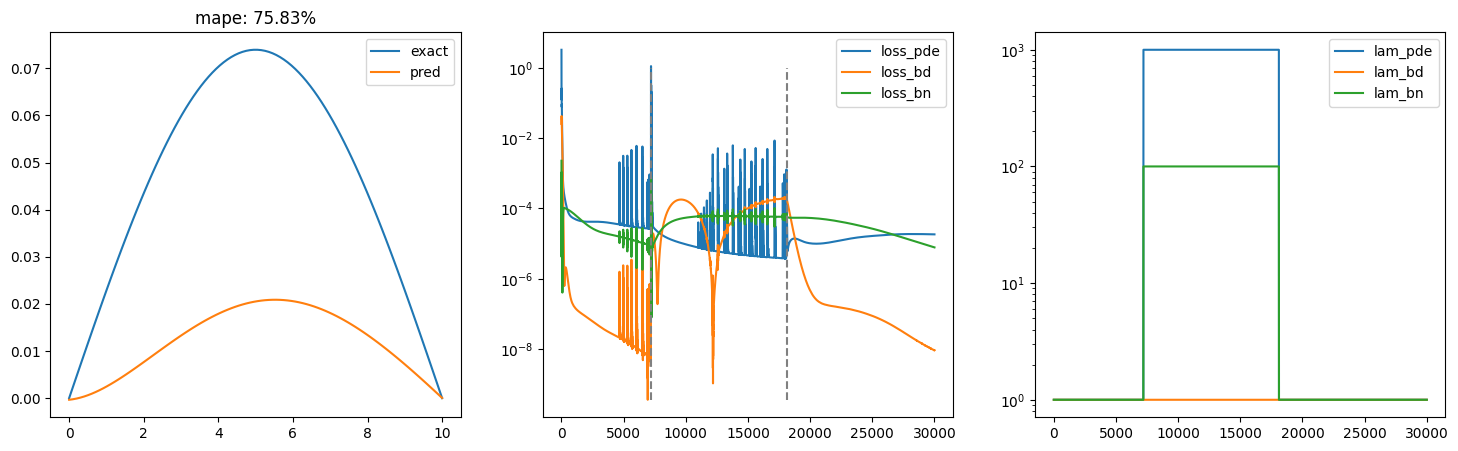

In [4]:
model.cpu()
x = torch.linspace(0,10,100).reshape(100,1)
u_exact = q_0*l**4/(np.pi**4*EI)*np.sin(np.pi*x/l)
u_pred = model(x).detach().numpy()
u_exact = np.array(u_exact, dtype=float)
u_exact[-1] = 0
u_pred = np.array(u_pred, dtype=float)
mask = u_exact != 0
mape = np.mean(np.abs((u_exact[mask] - u_pred[mask]) / u_exact[mask])) * 100


fig, ax = plt.subplots(1, 3, figsize=(18, 5))


ax[0].plot(x,u_exact, label='exact')
ax[0].plot(x,u_pred, label='pred')
ax[0].set_title(f'mape: {mape:.2f}%')
ax[0].legend()


loss_vec = np.array(loss_vec)
loss_to_hist = loss_vec[:,0]
loss_in_hist = loss_vec[:,1]
loss_bd_hist = loss_vec[:,2]
loss_bn_hist = loss_vec[:,3]
# ax[1].plot(loss_to_hist, label='loss_tot')
ax[1].plot(loss_in_hist, label='loss_pde')
ax[1].plot(loss_bd_hist, label='loss_bd')
ax[1].plot(loss_bn_hist, label='loss_bn')
ax[1].vlines(epoch_triggered, ymin=min(min(loss_in_hist), min(loss_bd_hist), min(loss_bn_hist)), ymax=1, linestyle='dashed', colors='gray')
ax[1].set_yscale('log')
ax[1].legend()

lambs_history  = np.array(lambs_history)
lam_in_histoty = lambs_history[:,0]
lam_bd_histoty = lambs_history[:,1]
lam_bn_histoty = lambs_history[:,2]
ax[2].plot(lam_in_histoty, label='lam_pde')
ax[2].plot(lam_bd_histoty, label='lam_bd')
ax[2].plot(lam_bn_histoty, label='lam_bn')
if exp == 'own' :
    ax[2].set_yscale('log')
ax[2].legend()

plt.show()